# Volume Objective


In this example, we compute the maximal (resp. minimal) volume ellipsoids
and polynomial sublevel sets contained in (resp. containing) the square with
vertices $(\pm 1, \pm 1)$. We start by defining the square with
[Polyhedra](https://github.com/JuliaPolyhedra/Polyhedra.jl).

In [1]:
using Polyhedra
h = HalfSpace([1, 0], 1.0) ∩ HalfSpace([-1, 0], 1) ∩ HalfSpace([0, 1], 1) ∩ HalfSpace([0, -1], 1)
p = polyhedron(h)

Polyhedron DefaultPolyhedron{Float64, Polyhedra.Intersection{Float64, Vector{Float64}, Int64}, Polyhedra.Hull{Float64, Vector{Float64}, Int64}}:
4-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([1.0, 0.0], 1.0)
 HalfSpace([-1.0, 0.0], 1.0)
 HalfSpace([0.0, 1.0], 1.0)
 HalfSpace([0.0, -1.0], 1.0)

We need to pick an SDP solver, see
[here](https://jump.dev/JuMP.jl/stable/installation/#Supported-solvers)
for a list of available ones.

In [2]:
using SetProg
import CSDP
sdp_solver = optimizer_with_attributes(CSDP.Optimizer, MOI.Silent() => true)

MathOptInterface.OptimizerWithAttributes(CSDP.Optimizer, Pair{MathOptInterface.AbstractOptimizerAttribute, Any}[MathOptInterface.Silent() => true])

## John ellipsoid

The maximal volume ellipsoid contained in a convex body is called its John
ellipsoid. The John ellipsoid for our square can be computed as follows.

In [3]:
model = Model(sdp_solver)
@variable(model, john, Ellipsoid(symmetric=true, dimension=2))
@constraint(model, john ⊆ p)
@objective(model, Max, nth_root(volume(john)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
SetProg.Sets.print_support_function(value(john))

solve_time(model) = 0.004286050796508789
termination_status(model) = OPTIMAL
objective_value(model) = 0.9999999996288853
h(S, x) = x[2]^2 + x[1]^2


## Löwner ellipsoid

The minimal volume ellipsoid containing a convex body is called its Löwner
ellipsoid. The Löwner ellipsoid for our square can be computed as follows.

In [4]:
model = Model(sdp_solver)
@variable(model, löwner, Ellipsoid(symmetric=true, dimension=2))
@constraint(model, p ⊆ löwner)
@objective(model, Min, nth_root(volume(löwner)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
löwner_value = value(löwner)

solve_time(model) = 0.004060983657836914
termination_status(model) = OPTIMAL
objective_value(model) = 0.49999999967800046


SetProg.Sets.Ellipsoid{Float64}([0.5000000159896161 2.220446049250313e-16; 2.220446049250313e-16 0.499999983688292])

We can visualize the Löwner and John ellipsoids as follows.

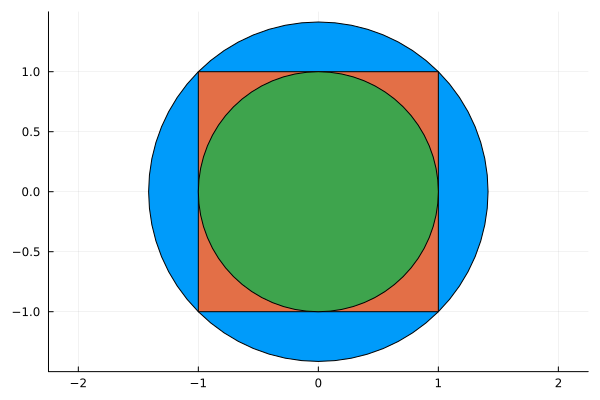

In [5]:
using Plots
plot(ratio=:equal)
plot!(löwner_value)
plot!(p)
plot!(value(john))

## Higher degree polynomials

Ellipsoids are the sublevel sets of positive definite *quadratic* forms. To
allow for more sophisticated shapes, we instead look for sublevel sets of
*quartic* forms. For this, we simply replace `Ellipsoid(dimension=2)` by
`PolySet(degree=4, dimension=2)`. Note that the quantities optimized are
not exactly the volume anymore but provide a reasonable heuristic.

### Maximal volume quartic sublevel set contained in the square

In [6]:
model = Model(sdp_solver)
@variable(model, quartic_inner, PolySet(degree=4, symmetric=true, convex=true))
@constraint(model, quartic_inner ⊆ p)
@objective(model, Max, nth_root(volume(quartic_inner)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
quartic_inner_value = value(quartic_inner)

solve_time(model) = 0.008144855499267578
termination_status(model) = OPTIMAL
objective_value(model) = 6.447419587070315


SetProg.Sets.Polar{Float64, SetProg.Sets.ConvexPolySet{Float64, StarAlgebras.SubBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Int64, Vector{Int64}, StarAlgebras.MappedBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Vector{Int64}, MultivariatePolynomials.ExponentsIterator{MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}, Nothing, Vector{Int64}}, MultivariateBases.Variables{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}}, typeof(MultivariatePolynomials.exponents)}, Vector{Vector{Int64

### Minimal volume quartic sublevel set containing the square

In [7]:
model = Model(sdp_solver)
@variable(model, quartic_outer, PolySet(symmetric=true, degree=4, convex=true))
@constraint(model, p ⊆ quartic_outer)
@objective(model, Min, nth_root(volume(quartic_outer)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
quartic_outer_value = value(quartic_outer)

solve_time(model) = 0.008232831954956055
termination_status(model) = OPTIMAL
objective_value(model) = 1.6118548945869895


SetProg.Sets.ConvexPolySet{Float64, StarAlgebras.SubBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Int64, Vector{Int64}, StarAlgebras.MappedBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Vector{Int64}, MultivariatePolynomials.ExponentsIterator{MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}, Nothing, Vector{Int64}}, MultivariateBases.Variables{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}}, typeof(MultivariatePolynomials.exponents)}, Vector{Vector{Int64}}}, Float64}(4, GramMatrix 

We can visualize the quartic sublevel sets as follows.

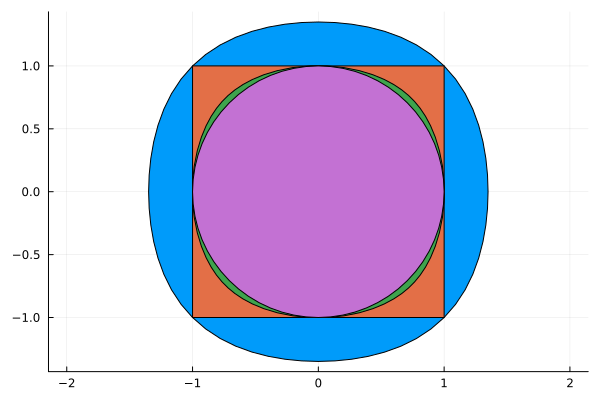

In [8]:
plot(ratio=:equal)
plot!(quartic_outer_value)
plot!(p)
plot!(quartic_inner_value)
plot!(value(john))

### Inner sublevel sets of increasing degree

We can also explore how the inner sublevel set tightens as the degree grows,
using the `L1_heuristic` as a tractable volume proxy.

solve_time(model) = 0.0019059181213378906
termination_status(model) = OPTIMAL
objective_value(model) = 0.6666666661961924
solve_time(model) = 0.0023260116577148438
termination_status(model) = OPTIMAL
objective_value(model) = 0.3999999986064172
solve_time(model) = 0.003384113311767578
termination_status(model) = OPTIMAL
objective_value(model) = 0.2857142830880059
solve_time(model) = 0.003180980682373047
termination_status(model) = OPTIMAL
objective_value(model) = 0.22628884587406972
solve_time(model) = 0.0041961669921875
termination_status(model) = OPTIMAL
objective_value(model) = 0.1842523412281417


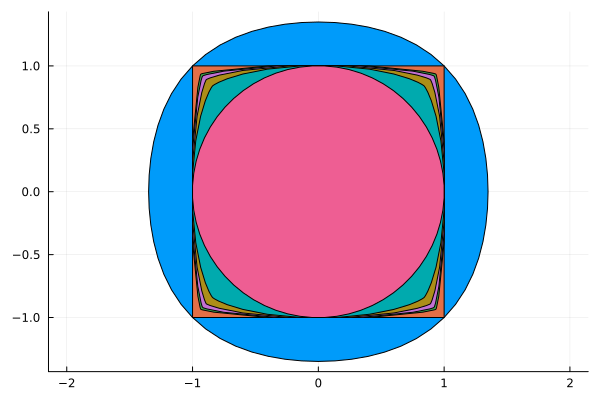

In [9]:
function inner_L1(d)
    model = Model(sdp_solver)
    @variable(model, S, PolySet(symmetric=true, degree=d, convex=true))
    @constraint(model, S ⊆ p)
    @objective(model, Max, L1_heuristic(volume(S), [1.0, 1.0]))
    optimize!(model)
    @show solve_time(model)
    @show termination_status(model)
    @show objective_value(model)
    return value(S)
end

S2 = inner_L1(2)
S4 = inner_L1(4)
S6 = inner_L1(6)
S8 = inner_L1(8)
S10 = inner_L1(10)

plot(ratio=:equal)
plot!(quartic_outer_value)
plot!(p)
plot!(S10)
plot!(S8)
plot!(S6)
plot!(S4)
plot!(S2)

## Non-homogeneous case

For non-symmetric bodies, the John/Löwner ellipsoids are not centered at the
origin. We need to provide a `point` as a hint of an interior point. We
illustrate on a horizontally-shifted square.

solve_time(model) = 0.004966020584106445
termination_status(model) = OPTIMAL
objective_value(model) = 0.30437682719196113


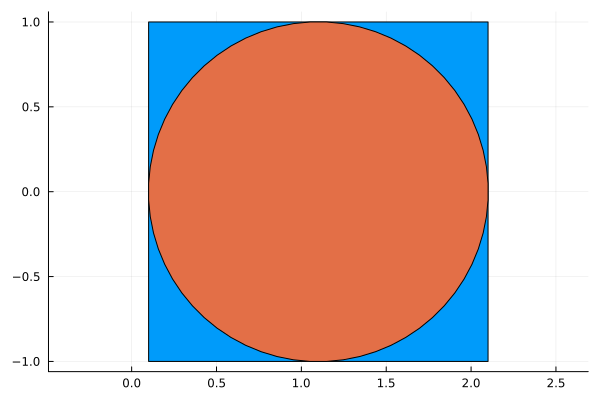

In [10]:
shift = 1.1
h_shift = HalfSpace([1, 0], 1.0 + shift) ∩ HalfSpace([-1, 0], 1.0 - shift) ∩ HalfSpace([0, 1], 1) ∩ HalfSpace([0, -1], 1)
p_shift = polyhedron(h_shift)

model = Model(sdp_solver)
@variable(model, john_shift, Ellipsoid(point=SetProg.InteriorPoint([shift, 0.0])))
@constraint(model, john_shift ⊆ p_shift)
@objective(model, Max, nth_root(volume(john_shift)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)

plot(ratio=:equal)
plot!(p_shift)
plot!(value(john_shift))

Likewise for the quartic sublevel set.

solve_time(model) = 0.0021719932556152344
termination_status(model) = OPTIMAL
objective_value(model) = 0.8763129326715293


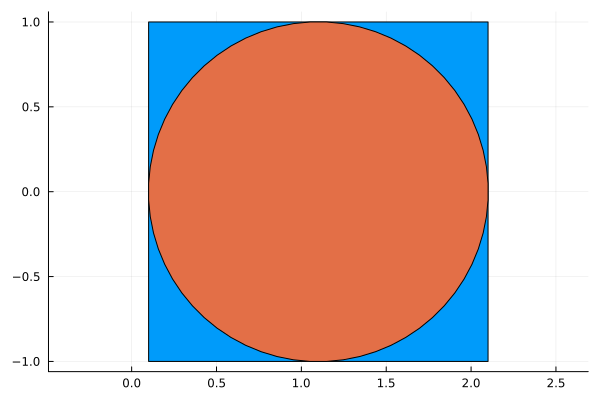

In [11]:
model = Model(sdp_solver)
@variable(model, quartic_shift, PolySet(convex=true, degree=2, point=SetProg.InteriorPoint([shift, 0.0])))
@constraint(model, quartic_shift ⊆ p_shift)
@objective(model, Max, L1_heuristic(volume(quartic_shift), [1.0, 1.0]))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)

plot(ratio=:equal)
plot!(p_shift)
plot!(value(quartic_shift))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*